# AI-Assisted AML Case Review & Decision Support System

## Overview
This project simulates an AI-assisted compliance case review tool designed to support analysts in reviewing transaction monitoring alerts more efficiently.

The assistant takes structured alert data and generates a concise case summary, a risk assessment, key risk drivers, and recommended next steps. It is designed to reflect how AI can improve productivity, consistency, and prioritisation in financial crime compliance workflows.

This simulates an AI-assisted decision support tool used by compliance analysts to enhance consistency and reduce manual review effort.

## Objective
- Simulate AI-assisted case review in a compliance setting
- Summarise alert details into an investigation-ready format
- Assign a risk level based on key financial crime indicators
- Highlight the main drivers of risk
- Recommend follow-up actions for analysts

#### Libraries

In [1]:
import pandas as pd

#### Data

In [2]:
data = {
    "case_id": ["CASE001", "CASE002", "CASE003", "CASE004", "CASE005"],
    "customer_id": ["C001", "C002", "C003", "C004", "C005"],
    "country": ["HighRisk", "LowRisk", "MediumRisk", "HighRisk", "LowRisk"],
    "transaction_amount": [50000, 3000, 18000, 70000, 1500],
    "txn_count_7d": [15, 2, 9, 20, 1],
    "is_pep": ["Yes", "No", "No", "No", "No"],
    "is_sanction_hit": ["No", "No", "Yes", "No", "No"],
    "previous_alerts": [4, 0, 2, 5, 0],
    "alert_reason": [
        "High transaction volume and high-risk country",
        "Single moderate transaction",
        "Sanctions screening match",
        "Frequent high-value transactions in high-risk jurisdiction",
        "Low-value transaction"
    ]
}

df = pd.DataFrame(data)
df

,case_id,customer_id,country,transaction_amount,txn_count_7d,is_pep,is_sanction_hit,previous_alerts,alert_reason
0,CASE001,C001,HighRisk,50000,15,Yes,No,4,High transaction volume and high-risk country
1,CASE002,C002,LowRisk,3000,2,No,No,0,Single moderate transaction
2,CASE003,C003,MediumRisk,18000,9,No,Yes,2,Sanctions screening match
3,CASE004,C004,HighRisk,70000,20,No,No,5,Frequent high-value transactions in high-risk ...
4,CASE005,C005,LowRisk,1500,1,No,No,0,Low-value transaction


## Risk Assessment Logic

The assistant uses a simple rules-based approach to simulate how an AI system might assess risk and explain its decision.

The purpose is not to replicate a production model, but to demonstrate how alert data can be translated into investigation-ready outputs.

In [3]:
def assign_risk_level(row):
    if row["is_sanction_hit"] == "Yes":
        return "High"
    if row["is_pep"] == "Yes" and row["transaction_amount"] > 20000:
        return "High"
    if row["country"] == "HighRisk" and row["txn_count_7d"] > 10:
        return "High"
    if row["transaction_amount"] > 10000 or row["txn_count_7d"] > 7:
        return "Medium"
    return "Low"

In [4]:
def get_risk_drivers(row):
    drivers = []

    if row["is_sanction_hit"] == "Yes":
        drivers.append("Sanctions screening match")
    if row["is_pep"] == "Yes":
        drivers.append("Politically Exposed Person (PEP)")
    if row["country"] == "HighRisk":
        drivers.append("High-risk jurisdiction")
    if row["transaction_amount"] > 20000:
        drivers.append("Large transaction amount")
    if row["txn_count_7d"] > 10:
        drivers.append("High transaction frequency")
    if row["previous_alerts"] > 0:
        drivers.append("Previous alert history")

    return ", ".join(drivers) if drivers else "No major red flags identified"

In [5]:
def recommend_action(risk_level):
    if risk_level == "High":
        return "Escalate for immediate investigation and enhanced due diligence"
    elif risk_level == "Medium":
        return "Review supporting documentation and monitor for further activity"
    else:
        return "Queue for standard review"

In [6]:
def generate_case_summary(row):
    return (
        f"Case {row['case_id']} relates to customer {row['customer_id']} with "
        f"transaction activity of {row['transaction_amount']} across "
        f"{row['txn_count_7d']} transactions in the last 7 days. "
        f"Alert reason: {row['alert_reason']}."
    )

df["risk_level"] = df.apply(assign_risk_level, axis=1)
df["risk_drivers"] = df.apply(get_risk_drivers, axis=1)
df["recommended_action"] = df["risk_level"].apply(recommend_action)
df["case_summary"] = df.apply(generate_case_summary, axis=1)

df[["case_id", "case_summary", "risk_level", "risk_drivers", "recommended_action"]]

,case_id,case_summary,risk_level,risk_drivers,recommended_action
0,CASE001,Case CASE001 relates to customer C001 with tra...,High,"Politically Exposed Person (PEP), High-risk ju...",Escalate for immediate investigation and enhan...
1,CASE002,Case CASE002 relates to customer C002 with tra...,Low,No major red flags identified,Queue for standard review
2,CASE003,Case CASE003 relates to customer C003 with tra...,High,"Sanctions screening match, Previous alert history",Escalate for immediate investigation and enhan...
3,CASE004,Case CASE004 relates to customer C004 with tra...,High,"High-risk jurisdiction, Large transaction amou...",Escalate for immediate investigation and enhan...
4,CASE005,Case CASE005 relates to customer C005 with tra...,Low,No major red flags identified,Queue for standard review


## Analyst Review Output

The table below simulates the output an AI-assisted case review tool could generate for compliance analysts.

It converts structured alert data into a concise and actionable review format.

In [7]:
review_output = df[[
    "case_id",
    "case_summary",
    "risk_level",
    "risk_drivers",
    "recommended_action"
]]

review_output

,case_id,case_summary,risk_level,risk_drivers,recommended_action
0,CASE001,Case CASE001 relates to customer C001 with tra...,High,"Politically Exposed Person (PEP), High-risk ju...",Escalate for immediate investigation and enhan...
1,CASE002,Case CASE002 relates to customer C002 with tra...,Low,No major red flags identified,Queue for standard review
2,CASE003,Case CASE003 relates to customer C003 with tra...,High,"Sanctions screening match, Previous alert history",Escalate for immediate investigation and enhan...
3,CASE004,Case CASE004 relates to customer C004 with tra...,High,"High-risk jurisdiction, Large transaction amou...",Escalate for immediate investigation and enhan...
4,CASE005,Case CASE005 relates to customer C005 with tra...,Low,No major red flags identified,Queue for standard review


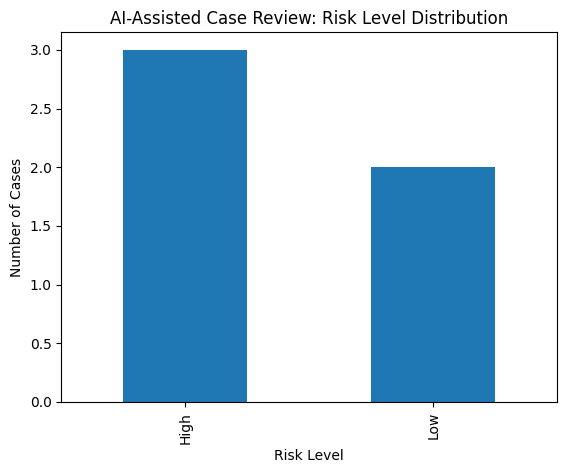

In [8]:
import matplotlib.pyplot as plt

df["risk_level"].value_counts().plot(kind="bar")
plt.title("AI-Assisted Case Review: Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Cases")
plt.show()

## Business Impact

This project demonstrates how AI-assisted tools can support financial crime compliance teams by:

- Reducing manual effort in case summarisation
- Improving consistency in alert review outputs
- Highlighting key risk drivers for faster analyst decision-making
- Supporting prioritisation of higher-risk alerts
- Enhancing productivity in transaction monitoring workflows

## Limitations

This project uses a simplified rules-based approach to simulate AI-assisted case review.

In a real-world setting, a production-grade system would require:
- Larger datasets
- Robust model validation
- Human review and escalation controls
- Explainability and governance standards
- Integration with case management and transaction monitoring systems

## Future Enhancements

Potential enhancements include:
- Integration with large language models for more natural case summarisation
- Automated drafting of investigator notes
- Interactive analyst interface using Streamlit
- Integration with transaction monitoring and sanctions screening systems
- Feedback loop to improve recommendation quality over time

In [9]:
def ai_explanation(row):
    return (
        f"The case is classified as {row['risk_level']} risk primarily due to "
        f"{row['risk_drivers']}. Based on these factors, the system recommends to "
        f"{row['recommended_action'].lower()}."
    )

In [10]:
df["ai_explanation"] = df.apply(ai_explanation, axis=1)

In [11]:
df[["case_id", "risk_level", "ai_explanation"]]

,case_id,risk_level,ai_explanation
0,CASE001,High,The case is classified as High risk primarily ...
1,CASE002,Low,The case is classified as Low risk primarily d...
2,CASE003,High,The case is classified as High risk primarily ...
3,CASE004,High,The case is classified as High risk primarily ...
4,CASE005,Low,The case is classified as Low risk primarily d...


## Key Insights

The AI-assisted approach demonstrates how structured alert data can be transformed into consistent, explainable, and actionable outputs.

By standardising case summaries and highlighting key risk drivers, the system reduces variability in analyst decision-making and supports more efficient case handling.

This reflects a shift towards augmented decision-making in financial crime compliance, where AI supports — rather than replaces — human investigators.

In [18]:
review_output

,case_id,case_summary,risk_level,risk_drivers,recommended_action
0,CASE001,Case CASE001 relates to customer C001 with tra...,High,"Politically Exposed Person (PEP), High-risk ju...",Escalate for immediate investigation and enhan...
1,CASE002,Case CASE002 relates to customer C002 with tra...,Low,No major red flags identified,Queue for standard review
2,CASE003,Case CASE003 relates to customer C003 with tra...,High,"Sanctions screening match, Previous alert history",Escalate for immediate investigation and enhan...
3,CASE004,Case CASE004 relates to customer C004 with tra...,High,"High-risk jurisdiction, Large transaction amou...",Escalate for immediate investigation and enhan...
4,CASE005,Case CASE005 relates to customer C005 with tra...,Low,No major red flags identified,Queue for standard review
